In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 1.0  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -1.06610865 Ha
FCI能量: -1.10115033 Ha


SpinOrbitalFermions 是 NetKet（特别是 netket ≥ v3.10 之后，或通过 netket.experimental）中用于描述具有自旋的费米子系统的希尔伯特空间（Hilbert space）类。它专为处理电子结构问题（如分子、固体中的多电子系统）而设计，天然支持泡利不相容原理和固定粒子数约束。

SpinOrbitalFermions 定义了一个由自旋轨道占据数构成的离散希尔伯特空间，每个自旋轨道只能被占据（1）或空（0），且满足：

费米子统计（自动通过占据数表示处理）
可选：固定总电子数、固定自旋向上/向下电子数


In [2]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
cluster = [(0,1),(2,3)]
#

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=[(0,1),(2,3)])
# g = nk.graph.Graph(edges=cluster)
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [3]:
hi.all_states()

Array([[0, 1, 0, 1],
       [0, 1, 1, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 0]], dtype=int8)

In [4]:
from flax import nnx
from jax.nn.initializers import lecun_normal
from typing import Any
import jax
from functools import partial
import jax.numpy as jnp

DType = Any
default_kernel_init = lecun_normal()


class LogNeuralJastrowSlater(nnx.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    def __init__(
        self,
        hilbert,
        jastrow_hidden_units: int,
        kernel_init=default_kernel_init,
        param_dtype=float,
        *,
        rngs: nnx.Rngs,
    ):
        self.hilbert = hilbert

        # To generate random numbers we need to extract the key from the `rngs` object.
        key = rngs.params()

        # the N x Nf matrix of the orbitals
        self.M = nnx.Param(
            kernel_init(
                key,
                (
                    self.hilbert.n_orbitals,
                    self.hilbert.n_fermions,
                ),
                param_dtype,
            )
        )

        # The Neural Jastrow wf
        # 修复：使用hilbert.size（总自旋轨道数）而不是hilbert.n_orbitals（空间轨道数）
        self.jastrow_linear = nnx.Linear(
            in_features=hilbert.size,  # 修复：使用总自旋轨道数
            out_features=jastrow_hidden_units,
            param_dtype=param_dtype,
            rngs=rngs,
        )

    def __call__(self, n: jax.Array) -> jax.Array:
        # For simplicity, we write a function that operates on a single configuration of size (N,)
        # and we vectorize it using `jnp.vectorize` with the signature='(n)->()' argument, which specifies
        # that the function is defined to operate on arrays of shape (n,) and return scalars.
        @partial(jnp.vectorize, signature="(n)->()")
        def log_sd(n):
            # Construct the Neural Jastrow
            J = self.jastrow_linear(n)
            J = jax.nn.tanh(J)
            J = J.sum()

            # Construct the slater determinant
            R = n.nonzero(size=self.hilbert.n_fermions)[0]
            # Extract from the (N, Nf) matrix the (Nf, Nf) submatrix of M corresponding to the occupied orbitals.
            A = self.M[R]
            log_slater = _logdet_cmplx(A)

            # Multiply log slater with the jastrow (and since we are working in log space, this becomes a sum)
            return log_slater + J

        return log_sd(n)


def _logdet_cmplx(A):
    # 计算复数矩阵的行列式的对数
    return jnp.linalg.slogdet(A)[1]

In [5]:
N = 4
ffnn_model = LogNeuralJastrowSlater(hi, jastrow_hidden_units=N, rngs=nnx.Rngs(2))
vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)

In [6]:
# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)

# 设置随机数种子
sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=False)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
gs.run(n_iter=300, out='H2_NeuralJastrow')

100%|██████████| 300/300 [00:05<00:00, 53.93it/s, Energy=-1.066e+00 ± 9.813e-18 [σ²=4.930e-32, R̂=0.9843]]


(JsonLog('H2_NeuralJastrow', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.025559663772583008
   	Params: 0.025525331497192383,)

In [7]:
# 读取能量数据
import json

with open('H2_NeuralJastrow.log', 'r') as f:
    data = json.load(f)

energy = data['Energy']['Mean']
energy_error = data['Energy']['Sigma']

print(f"Neural Jastrow-Slater能量: {energy[-1]:.8f} ± {energy_error[-1]:.8f} Ha")
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")
print(f"FCI能量: {E_fci:.8f} Ha")
print(f"与FCI的能量差: {abs(energy[-1] - E_fci):.8f} Ha")

Neural Jastrow-Slater能量: -1.06610865 ± 0.00000000 Ha
Hartree-Fock能量: -1.06610865 Ha
FCI能量: -1.10115033 Ha
与FCI的能量差: 0.03504168 Ha


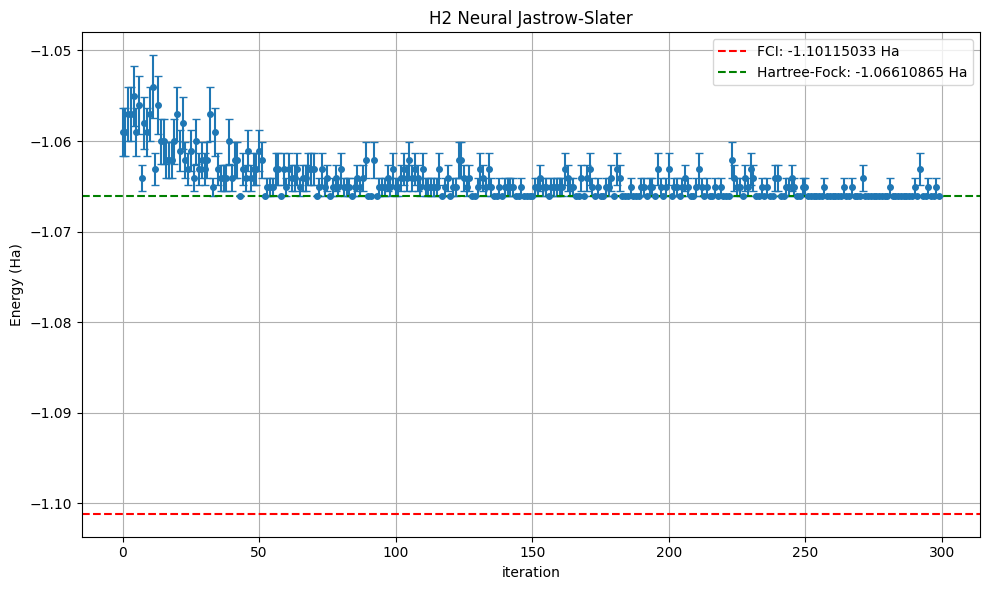

In [9]:
# 绘制能量收敛图
plt.figure(figsize=(10, 6))
plt.errorbar(range(len(energy)), energy, yerr=energy_error, fmt='o', markersize=4, capsize=3)
plt.axhline(y=E_fci, color='r', linestyle='--', label=f'FCI: {E_fci:.8f} Ha')
plt.axhline(y=E_hf, color='g', linestyle='--', label=f'Hartree-Fock: {E_hf:.8f} Ha')
plt.xlabel('iteration')
plt.ylabel('Energy (Ha)')
plt.title('H2 Neural Jastrow-Slater')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()